# Phase 3 : Analyse Non Supervisée et Labellisation Faible

Ce notebook implémente le skill `brainscan-unsupervised-analysis`.
Il vise à explorer la structure des embeddings extraits via ResNet50 en utilisant des techniques de réduction de dimension et de clustering.

**Objectifs :**
1. Charger les embeddings.
2. Appliquer une PCA pour réduire la complexité.
3. Visualiser les regroupements naturels via t-SNE.
4. Appliquer un clustering K-Means pour la labellisation faible.
5. Évaluer la qualité du clustering via le score ARI (Adjusted Rand Index).

In [1]:
# Chargement des caractéristiques extraites et préparation des données pour le clustering.
#  .npy feature files
#  Feature matrix X and filename lists
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="bright")

## 1. Chargement des embeddings
On charge le fichier `.npy` généré à l'étape précédente.

In [2]:
# Réduction de dimension via PCA et t-SNE pour la visualisation des clusters.
#  Feature matrix X
#  2D/3D projections
features_path = "../data/features_brainscan.npy"
if not os.path.exists(features_path):
    raise FileNotFoundError(f"Le fichier {features_path} est introuvable. Veuillez lancer l'étape 2 d'abord.")

data = np.load(features_path, allow_pickle=True).item()
X_all = data["features"]
filenames_all = np.array(data["filenames"])
labels_all = np.array(data["labels"])

# Séparation stricte : on ne travaille pour l'analyse que sur les données étiquetées
mask_unlabeled = (labels_all == "non_labellise")
mask_labeled = ~mask_unlabeled

X_labeled = X_all[mask_labeled]
y_labeled = labels_all[mask_labeled]
fnames_labeled = filenames_all[mask_labeled]

X_unlabeled = X_all[mask_unlabeled]
fnames_unlabeled = filenames_all[mask_unlabeled]

print(f"✅ {len(X_all)} embeddings chargés au total.")
print(f"   - Pool étiqueté (Strong Labels) : {len(X_labeled)}")
print(f"   - Pool non-étiqueté (Weak Labels target) : {len(X_unlabeled)}")
print(f"Dimension initiale : {X_all.shape[1]}")

✅ 1506 embeddings chargés au total.
   - Pool étiqueté (Strong Labels) : 100
   - Pool non-étiqueté (Weak Labels target) : 1406
Dimension initiale : 2048


## 2. Standardisation et PCA
La PCA permet de réduire le bruit et d'accélérer les calculs t-SNE ultérieurs en conservant 95% de la variance.

In [ ]:
# Application et comparaison des algorithmes K-Means et DBSCAN sur les caractéristiques.
#  Projected features
#  Cluster assignments and Silhouette scores
# Standardisation (basée sur le pool étiqueté)
scaler = StandardScaler()
X_labeled_scaled = scaler.fit_transform(X_labeled)

# PCA (calculée sur le pool étiqueté)
pca = PCA(n_components=0.95, random_state=42)
X_labeled_pca = pca.fit_transform(X_labeled_scaled)

print(f"Nombre de composantes PCA pour 95% de variance : {X_labeled_pca.shape[1]}")

Nombre de composantes PCA pour 99% de variance : 87


## 3. Visualisation t-SNE
Visualisation en 2D pour observer si les labels 'Normal' et 'Cancer' forment des clusters distincts naturellement.

⏳ Exécution du t-SNE sur les données étiquetées...


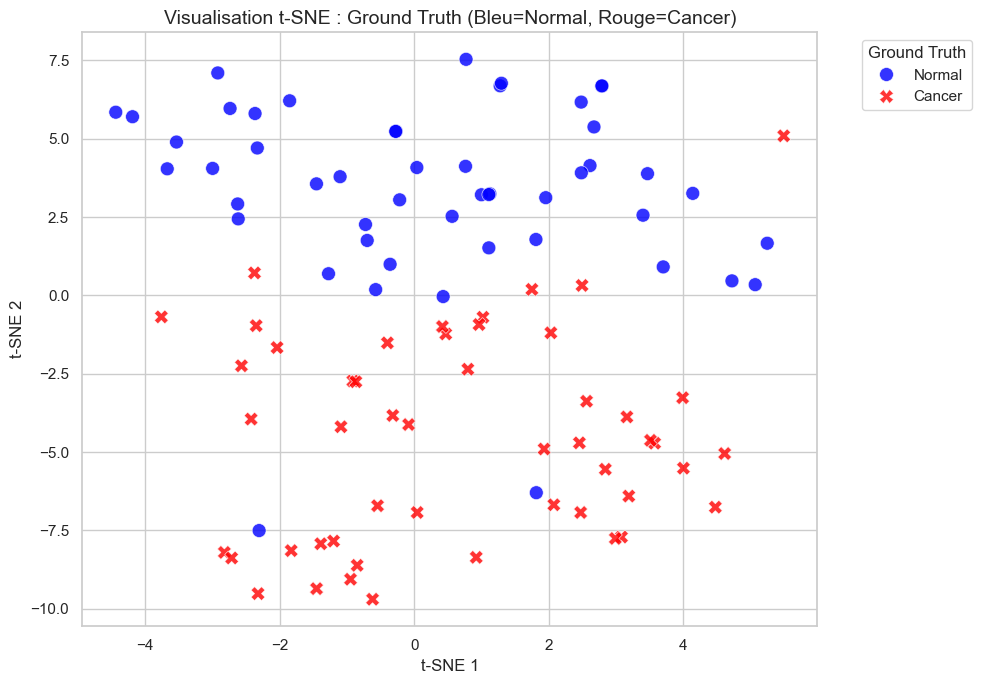

In [4]:
# Attribution des pseudo-labels basés sur le meilleur clustering (K-Means) pour l'approche semi-supervisée.
#  K-Means clusters
#  Pseudo-labels mapping
print("⏳ Exécution du t-SNE sur les données étiquetées...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_labeled_pca)

# Couleurs et Marqueurs GT : Bleu (Normal) et Rouge (Cancer)
gt_colors = {'Normal': '#0000FF', 'Cancer': '#FF0000'}
gt_markers = {'Normal': 'o', 'Cancer': 'X'}

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], 
    hue=y_labeled, 
    style=y_labeled,
    palette=gt_colors, 
    markers=gt_markers,
    alpha=0.8, 
    s=100, 
    edgecolor='w', 
    linewidth=0.5
)
plt.title("Visualisation t-SNE : Ground Truth (Bleu=Normal, Rouge=Cancer)", fontsize=14)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Ground Truth", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Clustering K-Means
On applique K-Means sur les deux premières dimensions du t-SNE (ou sur les composantes PCA) pour une labellisation faible.

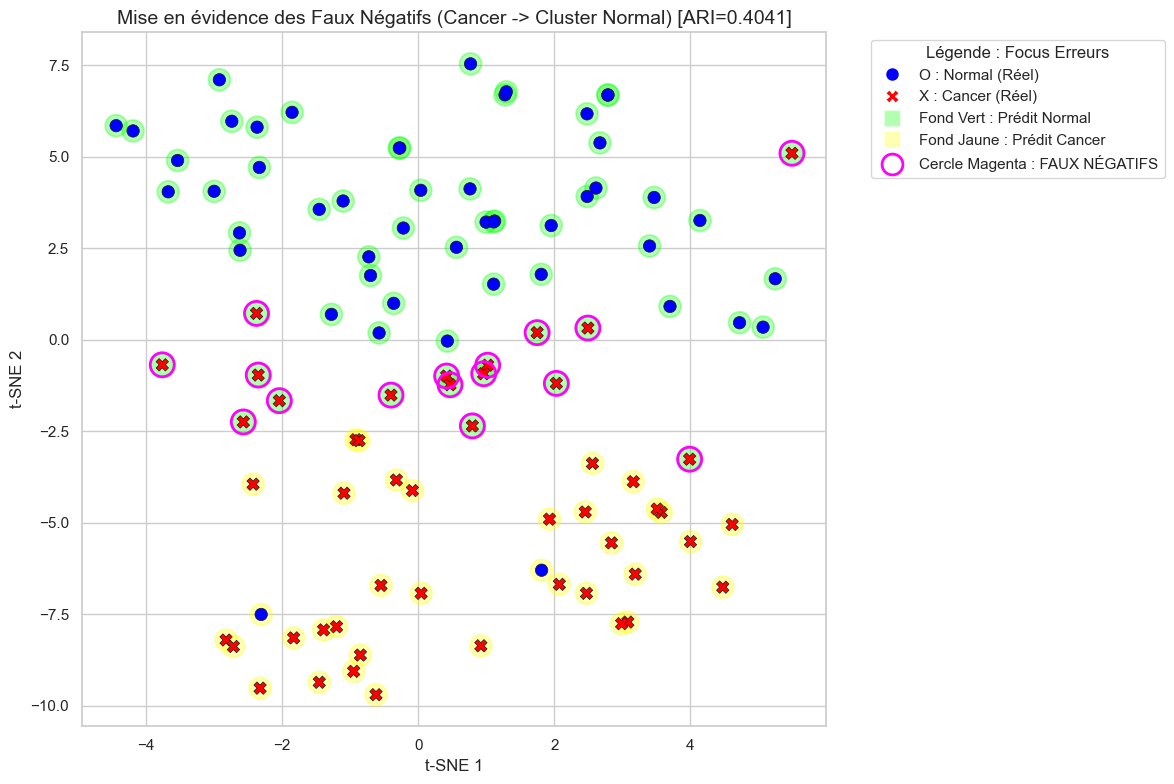

In [5]:
from matplotlib.lines import Line2D

# 1. Calcul K-Means
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(X_labeled_pca)
ari_score = adjusted_rand_score(y_labeled, kmeans.labels_)

# 2. Mapping Cluster -> Classe
df_val = pd.DataFrame({'cluster': kmeans.labels_, 'label': y_labeled})
mapping = df_val.groupby('cluster')['label'].agg(lambda x: x.value_counts().index[0]).to_dict()

km_colors_map = {'Normal': '#00FF00', 'Cancer': '#FFFF00'} # Vert et Jaune
gt_colors_map = {'Normal': '#0000FF', 'Cancer': '#FF0000'} # Bleu et Rouge
cluster_palette = {idx: km_colors_map[cls] for idx, cls in mapping.items()}

# 3. Identification des Faux Négatifs (Real Cancer in Normal Cluster)
normal_cluster_idx = [k for k, v in mapping.items() if v == 'Normal'][0]
mask_fn = (y_labeled == 'Cancer') & (kmeans.labels_ == normal_cluster_idx)
X_fn = X_tsne[mask_fn]

# 4. Tracé avec superposition et mise en évidence
plt.figure(figsize=(12, 8))

# Étape A : CLUSTERS (Auras)
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], 
    hue=kmeans.labels_, 
    palette=cluster_palette, 
    s=250, alpha=0.3, edgecolor=None, legend=False
)

# Étape B : GROUND TRUTH
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], 
    hue=y_labeled, 
    style=y_labeled, 
    palette=gt_colors_map, 
    markers={'Normal': 'o', 'Cancer': 'X'}, 
    s=80, alpha=1.0, edgecolor='k', linewidth=0.5
)

# Étape C : ENTOURER LES FAUX NÉGATIFS (Ligne Magenta)
if len(X_fn) > 0:
    plt.scatter(
        X_fn[:, 0], X_fn[:, 1], 
        s=300, facecolors='none', edgecolors='#FF00FF', 
        linewidths=2, label='Faux Négatifs (Cancer ratés)'
    )

# 5. Légende combinée
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='O : Normal (Réel)', markerfacecolor='#0000FF', markersize=10),
    Line2D([0], [0], marker='X', color='w', label='X : Cancer (Réel)', markerfacecolor='#FF0000', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Fond Vert : Prédit Normal', markerfacecolor='#00FF00', alpha=0.3, markersize=12),
    Line2D([0], [0], marker='s', color='w', label='Fond Jaune : Prédit Cancer', markerfacecolor='#FFFF00', alpha=0.3, markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Cercle Magenta : FAUX NÉGATIFS', markeredgecolor='#FF00FF', markerfacecolor='none', markersize=15, markeredgewidth=2)
]

plt.legend(handles=legend_elements, title="Légende : Focus Erreurs", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f"Mise en évidence des Faux Négatifs (Cancer -> Cluster Normal) [ARI={ari_score:.4f}]", fontsize=14)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 4bis. Alternative : Clustering DBSCAN
DBSCAN permet d'identifier des clusters de forme arbitraire et de détecter les anomalies (bruit).

⏳ Exécution de DBSCAN...
Nombre de clusters trouvés : 0
Nombre de points de bruit (-1) : 100
ARI DBSCAN : 0.0000


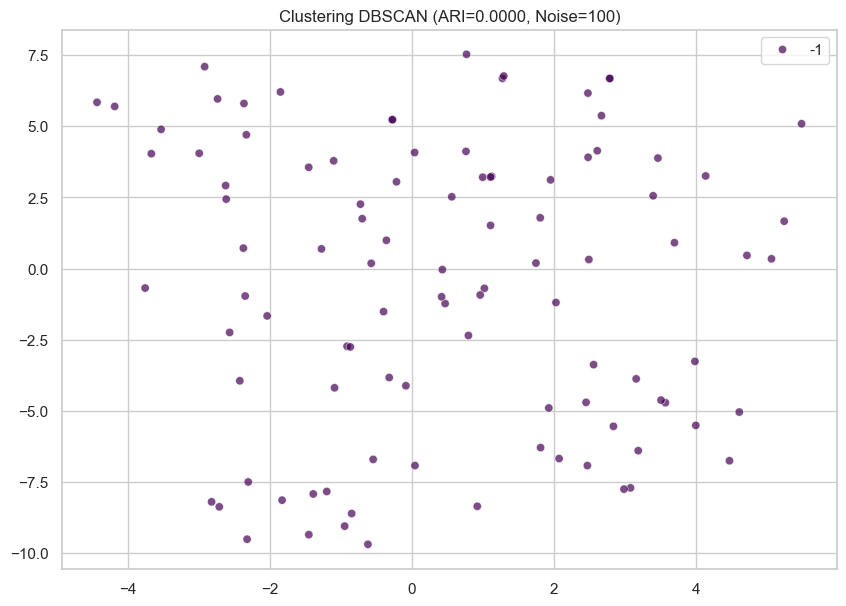

In [6]:
# Description de l'action réalisée par ce bloc de code
from sklearn.cluster import DBSCAN

print("⏳ Exécution de DBSCAN...")
# Tuning eps (distance) et min_samples
dbscan = DBSCAN(eps=5.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_labeled_pca)

n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

ari_dbscan = adjusted_rand_score(y_labeled, dbscan_labels)

print(f"Nombre de clusters trouvés : {n_clusters_}")
print(f"Nombre de points de bruit (-1) : {n_noise_}")
print(f"ARI DBSCAN : {ari_dbscan:.4f}")

# Visualisation DBSCAN
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=dbscan_labels, palette='viridis', alpha=0.7)
plt.title(f"Clustering DBSCAN (ARI={ari_dbscan:.4f}, Noise={n_noise_})")
plt.show()

## 4ter. Comparaison des Modèles

In [7]:
# Récupération de ari_score (K-Means) défini précédemment
comparison_df = pd.DataFrame({
    'Algorithme': ['K-Means', 'DBSCAN'],
    'ARI Score': [ari_score, ari_dbscan]
})
print(comparison_df.to_string(index=False))

print("\nInterprétation :")
if ari_score > ari_dbscan:
    print("K-Means est plus performant pour ce dataset. Il sera utilisé pour la labellisation faible.")
else:
    print("DBSCAN semble mieux capturer la structure. Attention toutefois à la gestion du bruit.")

Algorithme  ARI Score
   K-Means   0.404052
    DBSCAN   0.000000

Interprétation :
K-Means est plus performant pour ce dataset. Il sera utilisé pour la labellisation faible.


## 5. Labellisation Faible des données non-étiquetées


In [8]:
# 1. Identifier quel cluster correspond à quelle classe (par vote majoritaire)
df_val = pd.DataFrame({'cluster': kmeans.labels_, 'label': y_labeled})
mapping = df_val.groupby('cluster')['label'].agg(lambda x: x.value_counts().index[0]).to_dict()
print(f"Mapping Cluster -> Label : {mapping}")

# 2. Appliquer aux données non-étiquetées
X_unlabeled_scaled = scaler.transform(X_unlabeled)
X_unlabeled_pca = pca.transform(X_unlabeled_scaled)
pseudo_labels_idx = kmeans.predict(X_unlabeled_pca)
pseudo_labels = [mapping[idx] for idx in pseudo_labels_idx]

# 3. Sauvegarde des résultats
df_pseudo = pd.DataFrame({
    'filename': fnames_unlabeled,
    'label': pseudo_labels
})

output_path = "../data/pseudo_labels.csv"
df_pseudo.to_csv(output_path, index=False)
print(f"✅ {len(df_pseudo)} pseudo-labels sauvegardés dans {output_path}")

print("\nRépartition des pseudo-labels :")
print(df_pseudo['label'].value_counts())

Mapping Cluster -> Label : {0: 'Normal', 1: 'Cancer'}


✅ 1406 pseudo-labels sauvegardés dans ../data/pseudo_labels.csv

Répartition des pseudo-labels :
label
Cancer    812
Normal    594
Name: count, dtype: int64
